In [58]:
import pandas as pd 
import numpy as np 
import scipy.stats as stats 


In [59]:
columns_name = [
    "time", "gender", "matric_%", "study_year","faculty","gpa_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
survey=pd.read_csv("Stats survey.csv",names=columns_name,header=0)

In [60]:
survey

,time,gender,matric_%,study_year,faculty,gpa_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,2024/03/12 11:05:33 am EET,Female,74.0,NaN,Science,NaN,Private accommodation/ stay with family/friends,NaN,No,3-5,3,1-3,0,0,No,Yes,Close
402,2024/03/12 3:26:14 pm EET,Female,73.0,2nd Year,Economic & Management Sciences,58.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,"Yes (NSFAS, etc...)",5-8,1,8+,0,0,Yes,Yes,Very close
403,2024/03/13 10:32:19 pm EET,Female,86.0,1st Year,NaN,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,No,5-8,2,3-5,1,0,No,Yes,Very close
404,2024/03/13 10:32:27 pm EET,Male,85.0,NaN,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,No,1-3,4+,5-8,4+,0,No,Yes,Close


In [61]:
survey.drop("time",inplace=True,axis=1)

# EXPLORATORY DATA ANALYSIS(EDA)
1) find basic informations 
2) target specific :exploration and visualization 
3) corelation 

In [62]:
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           404 non-null    str    
 1   matric_%         399 non-null    float64
 2   study_year       333 non-null    str    
 3   faculty          399 non-null    str    
 4   gpa_2023         320 non-null    float64
 5   accomodation     383 non-null    str    
 6   allowance        375 non-null    str    
 7   scholarship      398 non-null    str    
 8   study_hours      403 non-null    str    
 9   party_week       404 non-null    str    
 10  drinks_night     404 non-null    str    
 11  missed_classes   403 non-null    str    
 12  failed_classes   403 non-null    str    
 13  in_relationship  403 non-null    str    
 14  parent_approve   402 non-null    str    
 15  relation_parent  403 non-null    str    
dtypes: float64(2), str(14)
memory usage: 50.9 KB


In [63]:
survey.isnull().sum()

gender              2
matric_%            7
study_year         73
faculty             7
gpa_2023           86
accomodation       23
allowance          31
scholarship         8
study_hours         3
party_week          2
drinks_night        2
missed_classes      3
failed_classes      3
in_relationship     3
parent_approve      4
relation_parent     3
dtype: int64

--description--

In [64]:
survey["gender"].value_counts(normalize=True)

gender
Male      0.534653
Female    0.465347
Name: proportion, dtype: float64

--description--

In [65]:
table=pd.crosstab(survey.parent_approve,survey.relation_parent)
table=table[["Distant","Fair","Close","Very close"]]

<Axes: xlabel='relation_parent'>

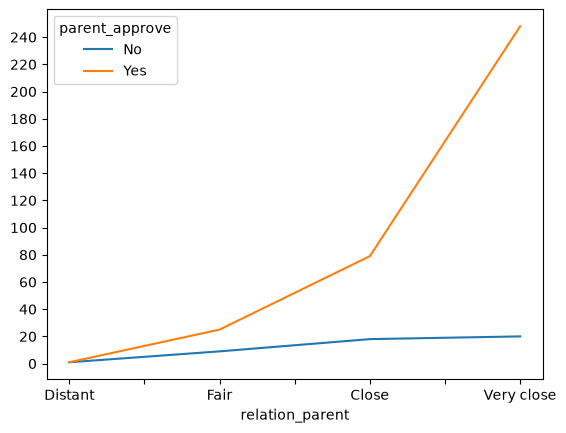

In [66]:
table.T.plot(kind="line",yticks=list(range(0,250,20)))


In [67]:
table.T,table

(parent_approve   No  Yes
 relation_parent         
 Distant           1    1
 Fair              9   25
 Close            18   79
 Very close       20  248,
 relation_parent  Distant  Fair  Close  Very close
 parent_approve                                   
 No                     1     9     18          20
 Yes                    1    25     79         248)

In [68]:
survey.columns 
table1=pd.crosstab(survey.gender,survey.in_relationship)

<Axes: xlabel='gender'>

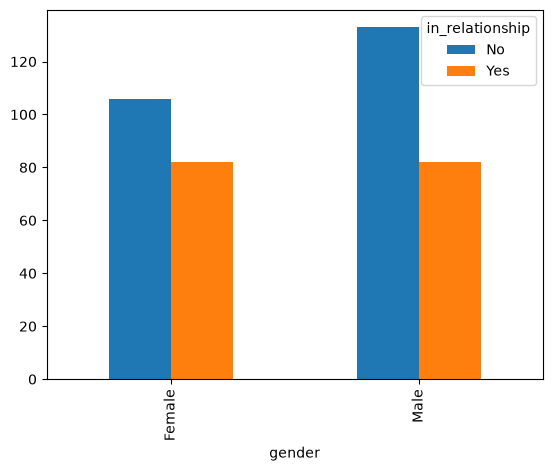

In [69]:
table1.plot(kind="bar")

In [70]:
survey.groupby("relation_parent")["matric_%"].mean().aggregate(("min","max","mean"))

min     77.690000
max     91.500000
mean    81.376814
Name: matric_%, dtype: float64

<Axes: xlabel='matric_%', ylabel='gpa_2023'>

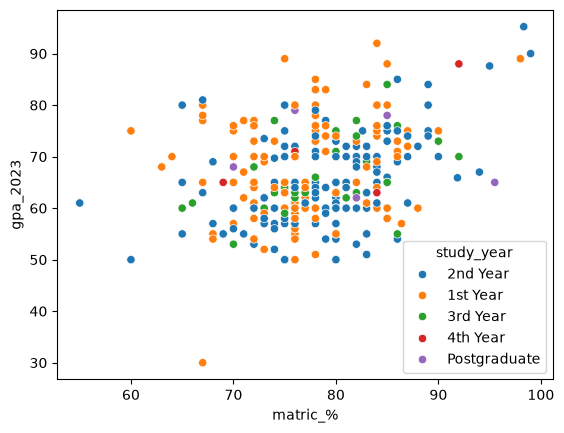

In [71]:
# relation between HS grade and 2023-grade
import seaborn as sns 
sns.scatterplot(survey,x="matric_%",y="gpa_2023",hue="study_year")

<Axes: xlabel='parent_approve', ylabel='gpa_2023'>

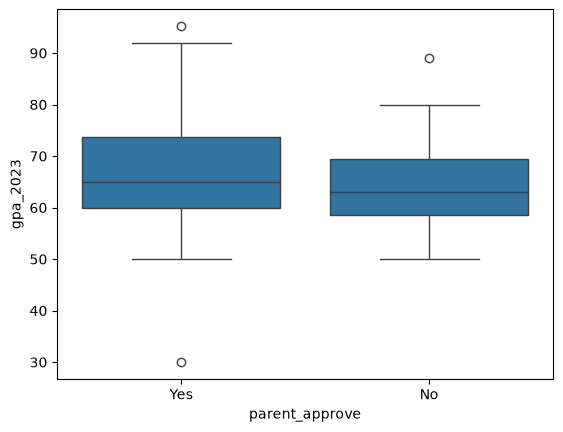

In [72]:
sns.boxplot(survey,y="gpa_2023",x="parent_approve")

# DATA MANUPULATION / CLEANING / TRANSFORMING / PREPROCESSING DATA 
1) removing unnecessary data 
2) null value handling
3) outlier handling 
4) feature engineering 
5) encoding / normalization /post-processing 

In [73]:
# REMOVE USING THRESHOLDING 
survey[~(survey.isna().sum(axis=1).values>=5)]
survey_1=survey.dropna(thresh=8)
survey.isnull().sum()

gender              2
matric_%            7
study_year         73
faculty             7
gpa_2023           86
accomodation       23
allowance          31
scholarship         8
study_hours         3
party_week          2
drinks_night        2
missed_classes      3
failed_classes      3
in_relationship     3
parent_approve      4
relation_parent     3
dtype: int64

In [74]:
survey_1.isna().sum()

gender              0
matric_%            5
study_year         71
faculty             5
gpa_2023           84
accomodation       21
allowance          29
scholarship         6
study_hours         1
party_week          0
drinks_night        0
missed_classes      1
failed_classes      1
in_relationship     1
parent_approve      2
relation_parent     1
dtype: int64

In [75]:
columnss=['gender','matric_%','study_year','faculty','scholarship','study_hours','party_week','drinks_night','missed_classes','failed_classes','in_relationship','parent_approve','relation_parent']
for column in survey_1.columns:
    if column in columnss:
        survey_1[column]=survey_1[column].fillna(survey_1[column].mode()[0],inplace=True)

C:\Users\My PC\AppData\Local\Temp\ipykernel_79348\92598028.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  survey_1[column]=survey_1[column].fillna(survey_1[column].mode()[0],inplace=True)


In [76]:
survey_1.isna().sum()

gender              0
matric_%            0
study_year          0
faculty             0
gpa_2023           84
accomodation       21
allowance          29
scholarship         0
study_hours         0
party_week          0
drinks_night        0
missed_classes      0
failed_classes      0
in_relationship     0
parent_approve      0
relation_parent     0
dtype: int64

In [77]:
survey_1.head(1)

,gender,matric_%,study_year,faculty,gpa_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close


In [78]:
# clearing null target values 
survey_2=survey_1.dropna(subset="gpa_2023")

In [79]:
# outlier detection and handling 

<Axes: >

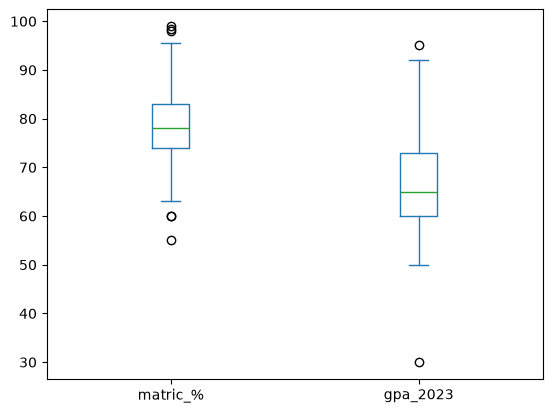

In [80]:
survey_2[["matric_%","gpa_2023"]].plot(kind="box")

In [81]:
def handle_outliers(series:pd.Series)->pd.Series:
    IQR=series.quantile(0.75)-series.quantile(0.25)
    max_value=series.quantile(0.75)+1.5*IQR
    min_value=series.quantile(0.25)-1.5*IQR
    outliers=series[(series.values>max_value) |(series.values<min_value)]
    print(outliers)
    return series.drop(outliers.index,axis=0)

In [82]:
survey_2.gpa2023=handle_outliers(survey_2.gpa_2023)

73     95.22
303    30.00
Name: gpa_2023, dtype: float64


C:\Users\My PC\AppData\Local\Temp\ipykernel_79348\2844417409.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  survey_2.gpa2023=handle_outliers(survey_2.gpa_2023)


In [83]:
survey_2.isnull().sum()

gender              0
matric_%            0
study_year          0
faculty             0
gpa_2023            0
accomodation        2
allowance          14
scholarship         0
study_hours         0
party_week          0
drinks_night        0
missed_classes      0
failed_classes      0
in_relationship     0
parent_approve      0
relation_parent     0
dtype: int64

In [84]:
def z_score(series:pd.Series)->pd.Series:
    mean_value=series.mean()
    std_value=series.std()
    z_score_value=(series-mean_value)/(std_value)
    outliers=series[abs(z_score_value)>3]
    print(outliers)
    return series.drop(outliers.index,axis=0)

In [85]:
survey_2["matric_%"]=z_score(survey_2["matric_%"])

38     99.00
54     98.00
73     98.33
335    55.00
Name: matric_%, dtype: float64


In [86]:
survey_2["accomodation"]=survey_2["accomodation"].fillna(survey_2["accomodation"].mode()[0])

In [87]:
survey_2.isna().sum()

gender              0
matric_%            4
study_year          0
faculty             0
gpa_2023            0
accomodation        0
allowance          14
scholarship         0
study_hours         0
party_week          0
drinks_night        0
missed_classes      0
failed_classes      0
in_relationship     0
parent_approve      0
relation_parent     0
dtype: int64

In [88]:
survey_2[survey_2["accomodation"].isna()]

,gender,matric_%,study_year,faculty,gpa_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent


In [89]:
survey_2.allowance=survey_2.allowance.fillna(survey_2.allowance.mode()[0])

In [90]:
survey_2["matric_%"]=handle_outliers(survey_2["matric_%"])

268    60.0
358    60.0
Name: matric_%, dtype: float64


In [96]:
survey_2["matric_%"]=survey["matric_%"].fillna(survey["matric_%"].mode()[0])

In [99]:
survey_2.to_csv("survey_cleaned.csv")

In [105]:
survey_2
from sklearn.preprocessing import OneHotEncoder 
one_hot_encoder=OneHotEncoder(sparse_output=False)
encoded=one_hot_encoder.fit_transform(survey_2[["gender"]])
encoded_df=pd.DataFrame(encoded,columns=one_hot_encoder.categories_)

,Female,Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
315,1.0,0.0
316,0.0,1.0
317,1.0,0.0
318,1.0,0.0
